In [ ]:
# Upgrade numpy and install required packages
!pip install numpy --upgrade
!pip install torch torchvision matplotlib seaborn pandas thop --quiet


In [ ]:
%cd /content
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt


/content
fatal: destination path 'yolov5' already exists and is not an empty directory.
/content/yolov5


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="CwCKuQPXA4DH0UT65qFZ")
project = rf.workspace("yolov5-tkc7d").project("yolo-u1voh")
version = project.version(1)
dataset = version.download("yolov5")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 116.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to yolo-1 in yolov5pytorch:: 100%|██████████| 676/676 [00:00<00:00, 8486.00it/s]


In [ ]:
!python train.py \
  --img 640 \
  --batch 16 \
  --epochs 70 \
  --data /content/yolov5/yolo-1/data.yaml \
  --weights yolov5s.pt \
  --name emotion_posture_model_final \
  --project runs/train \
  --exist-ok


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2025-08-11 15:00:26.220232: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754924426.478430    3335 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754924426.547349    3335 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS wh

In [ ]:
!python val.py \
  --data /content/yolov5/yolo-1/data.yaml \
  --weights runs/train/emotion_posture_model_final/weights/best.pt \
  --img 640 \
  --task val \
  --project runs/val \
  --name eval_results \
  --exist-ok


val: data=/content/yolov5/yolo-1/data.yaml, weights=['runs/train/emotion_posture_model_final/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=eval_results, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 v7.0-423-g567c6646 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/yolov5/yolo-1/valid/labels.cache... 67 images, 34 backgrounds, 0 corrupt: 100% 67/67 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 3/3 [00:02<00:00,  1.01it/s]
                   all         67         61          1      0.995      0.995      0.994
Speed: 0.5ms pre-process, 10.1ms inference, 4.4ms NMS per image at shape (32,

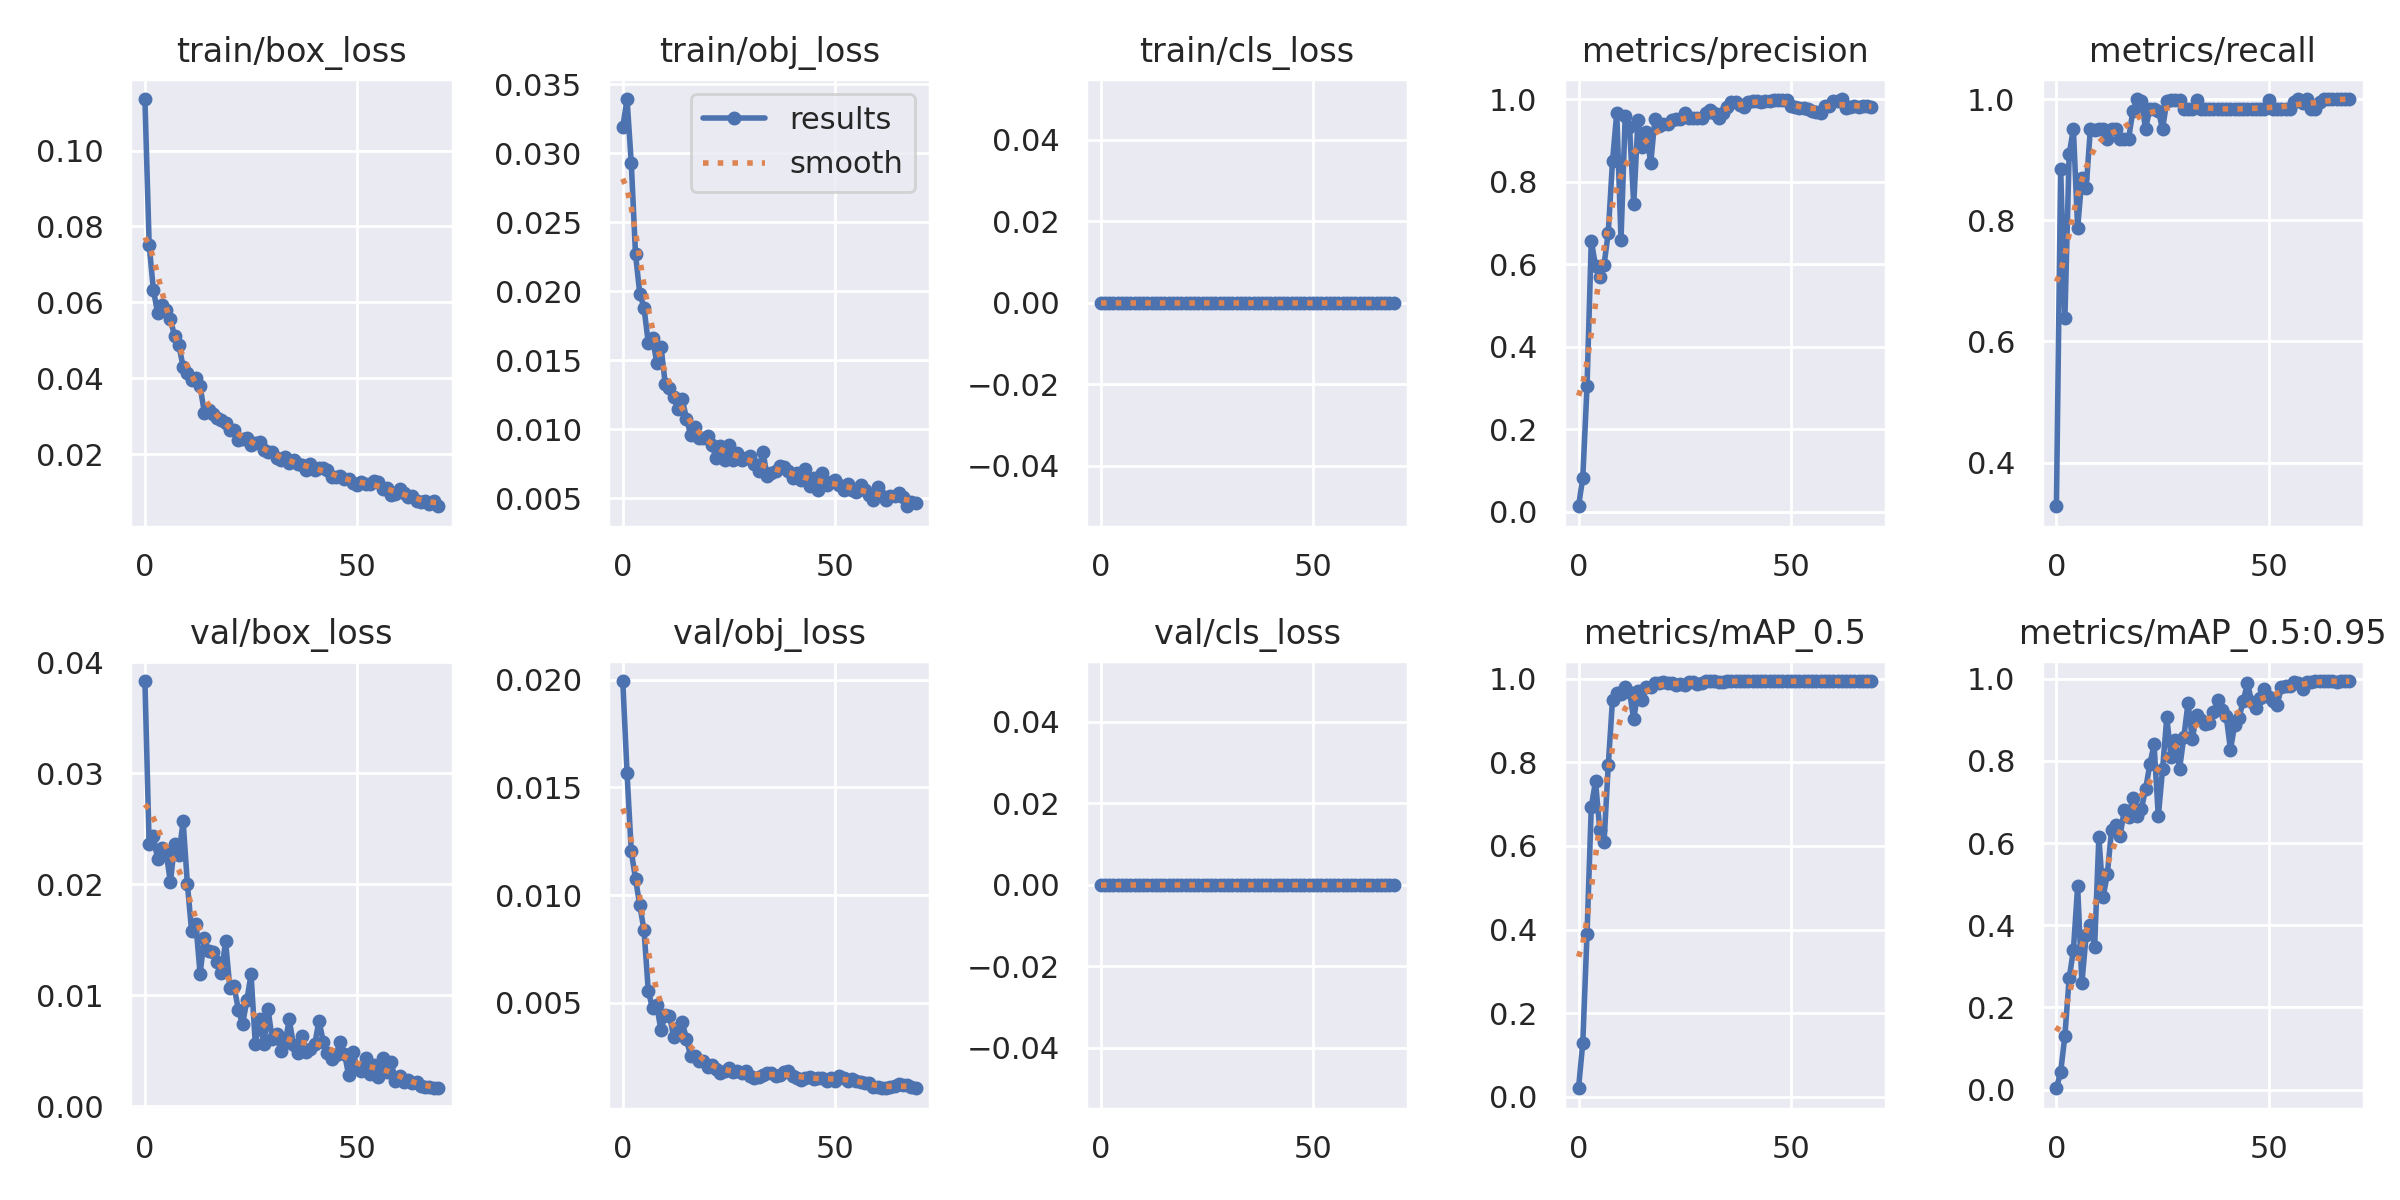

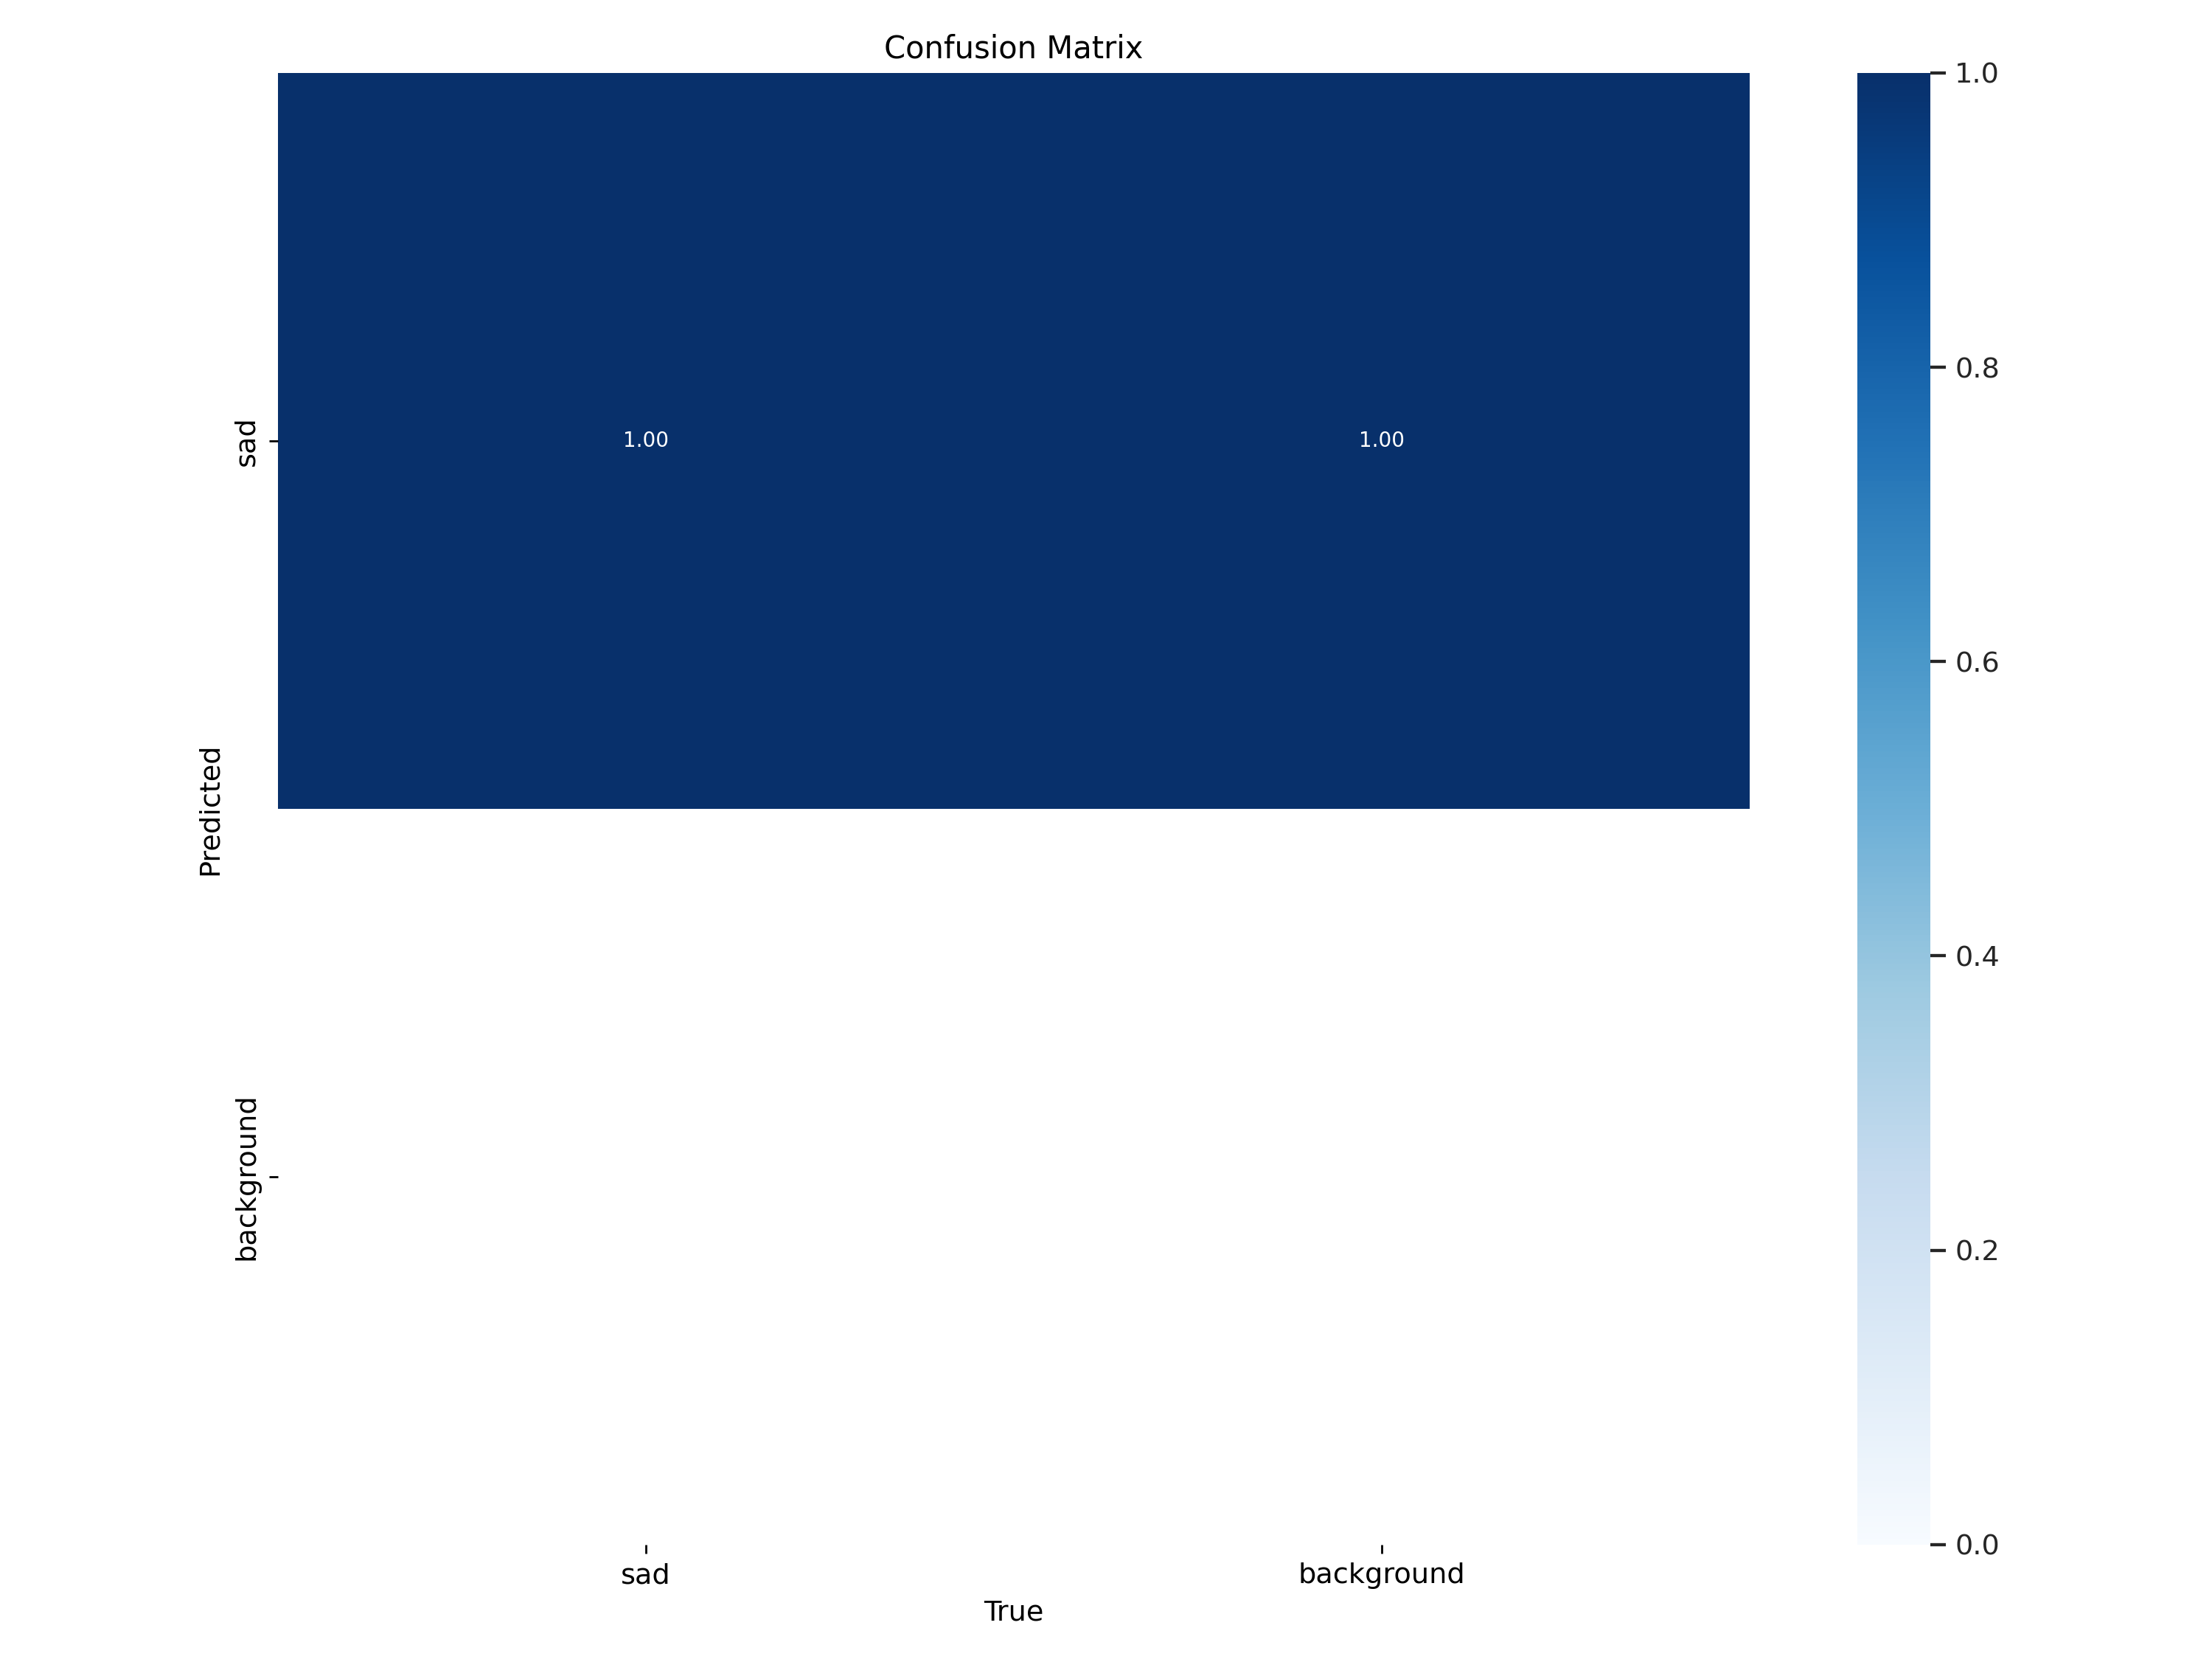

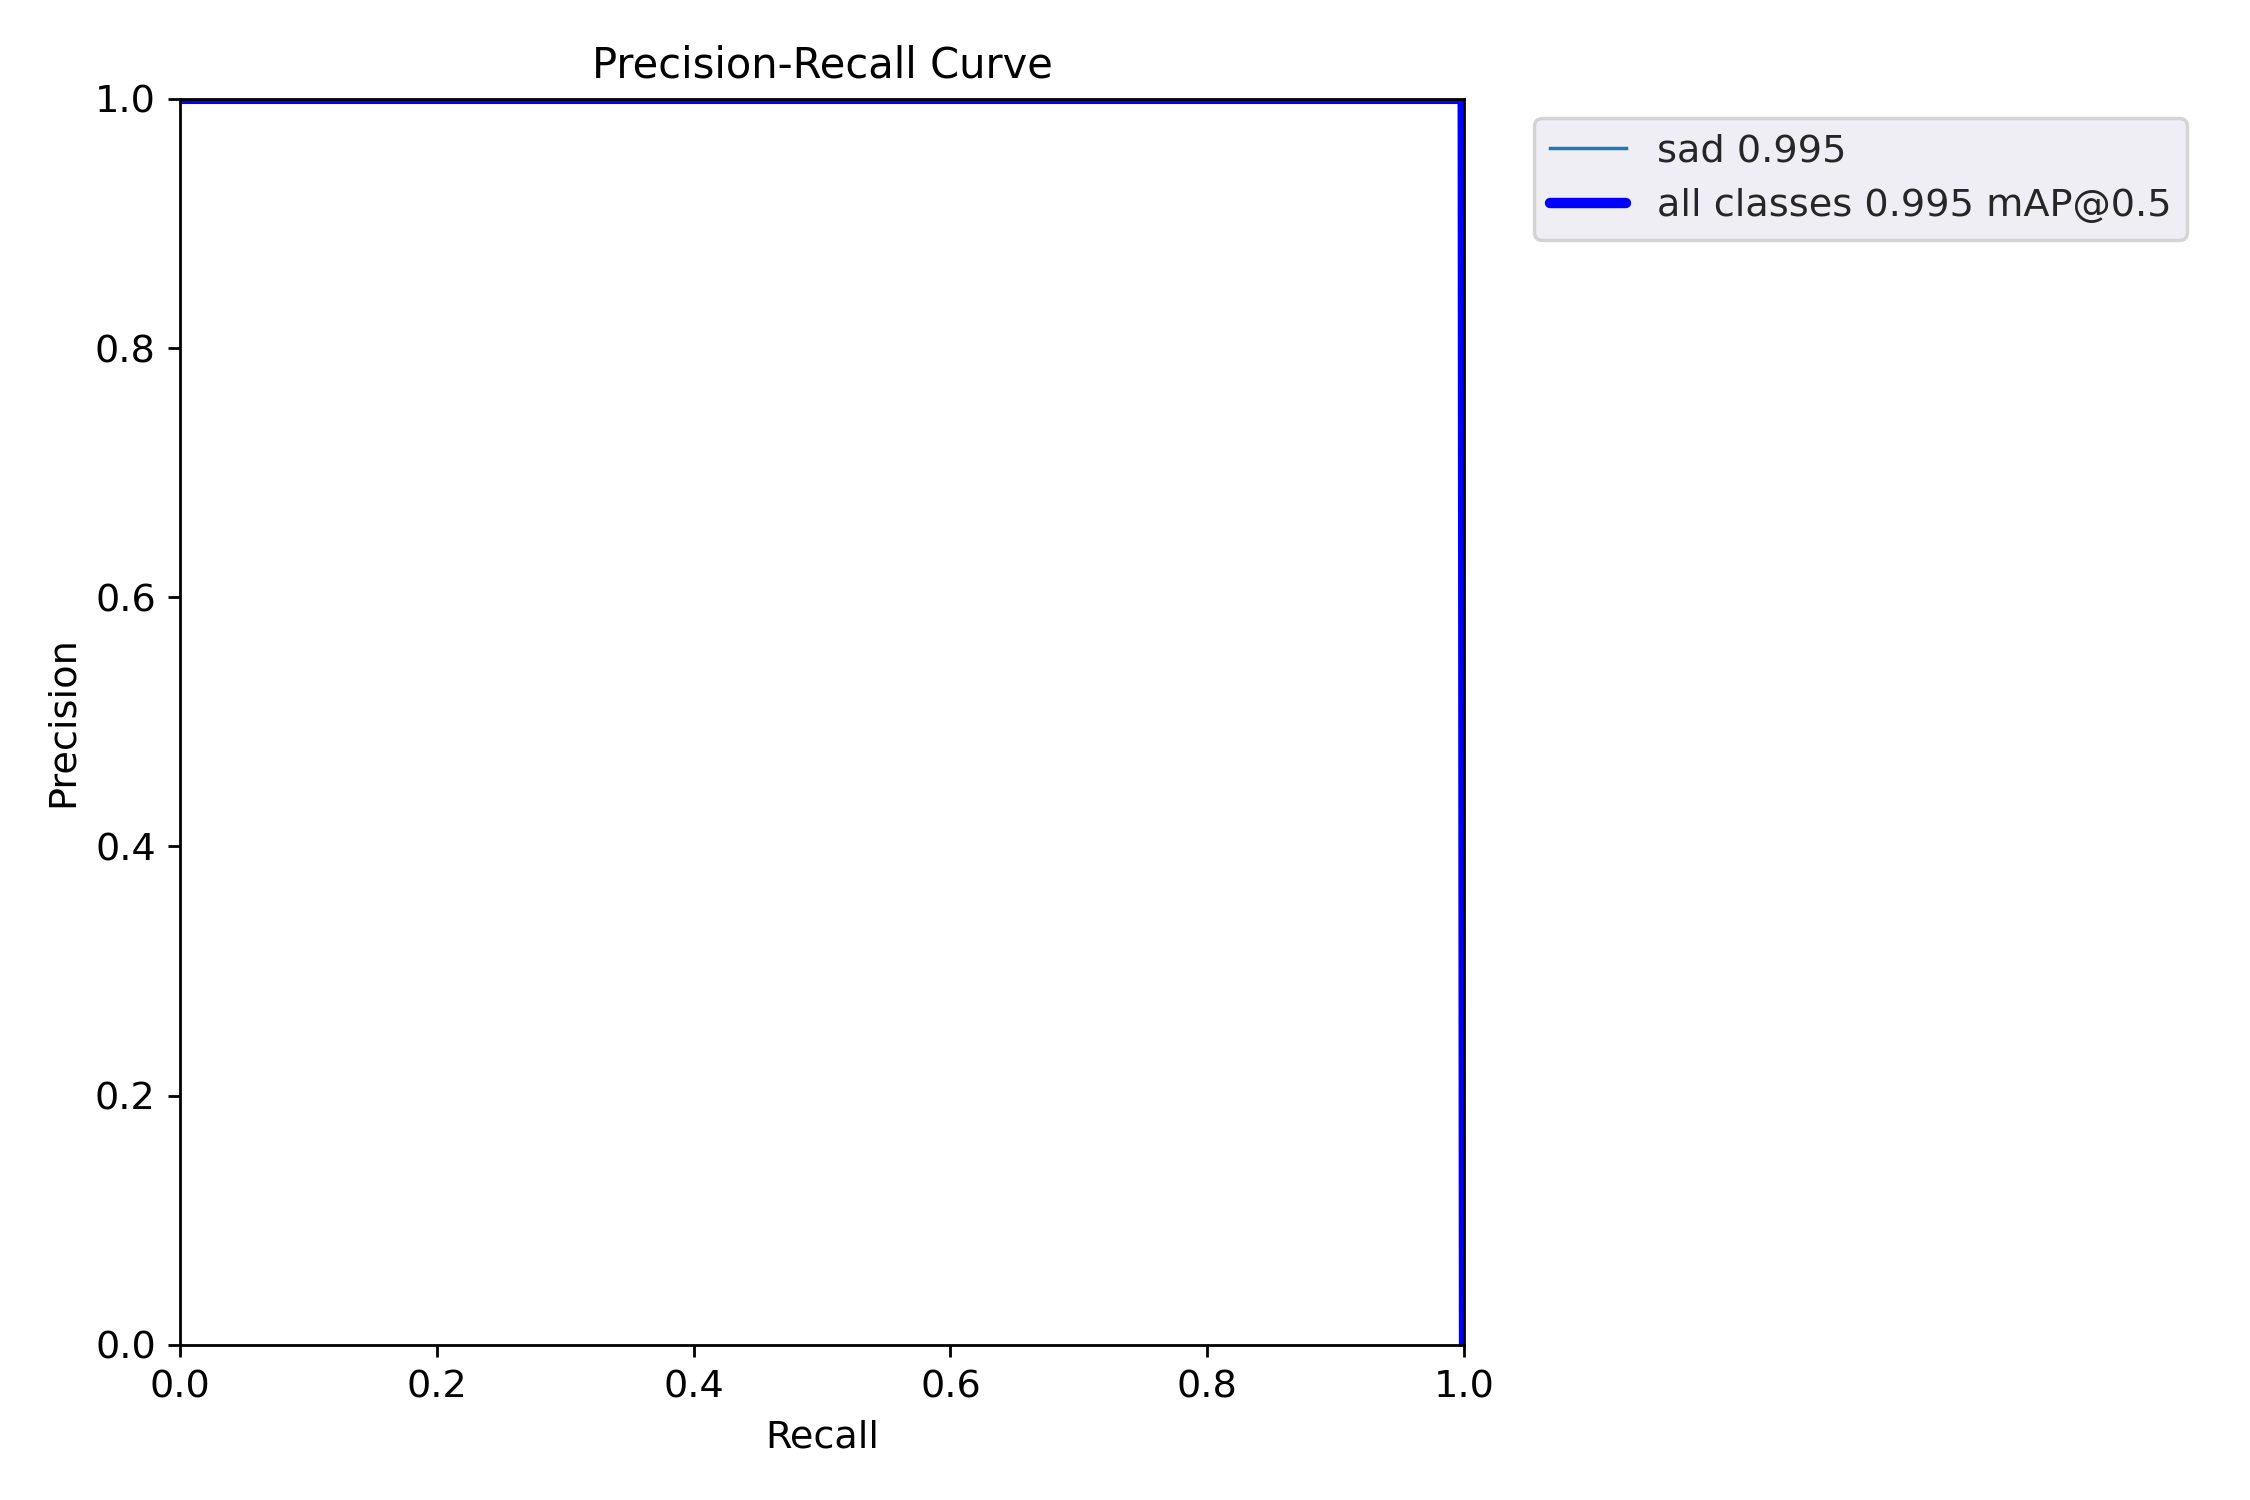

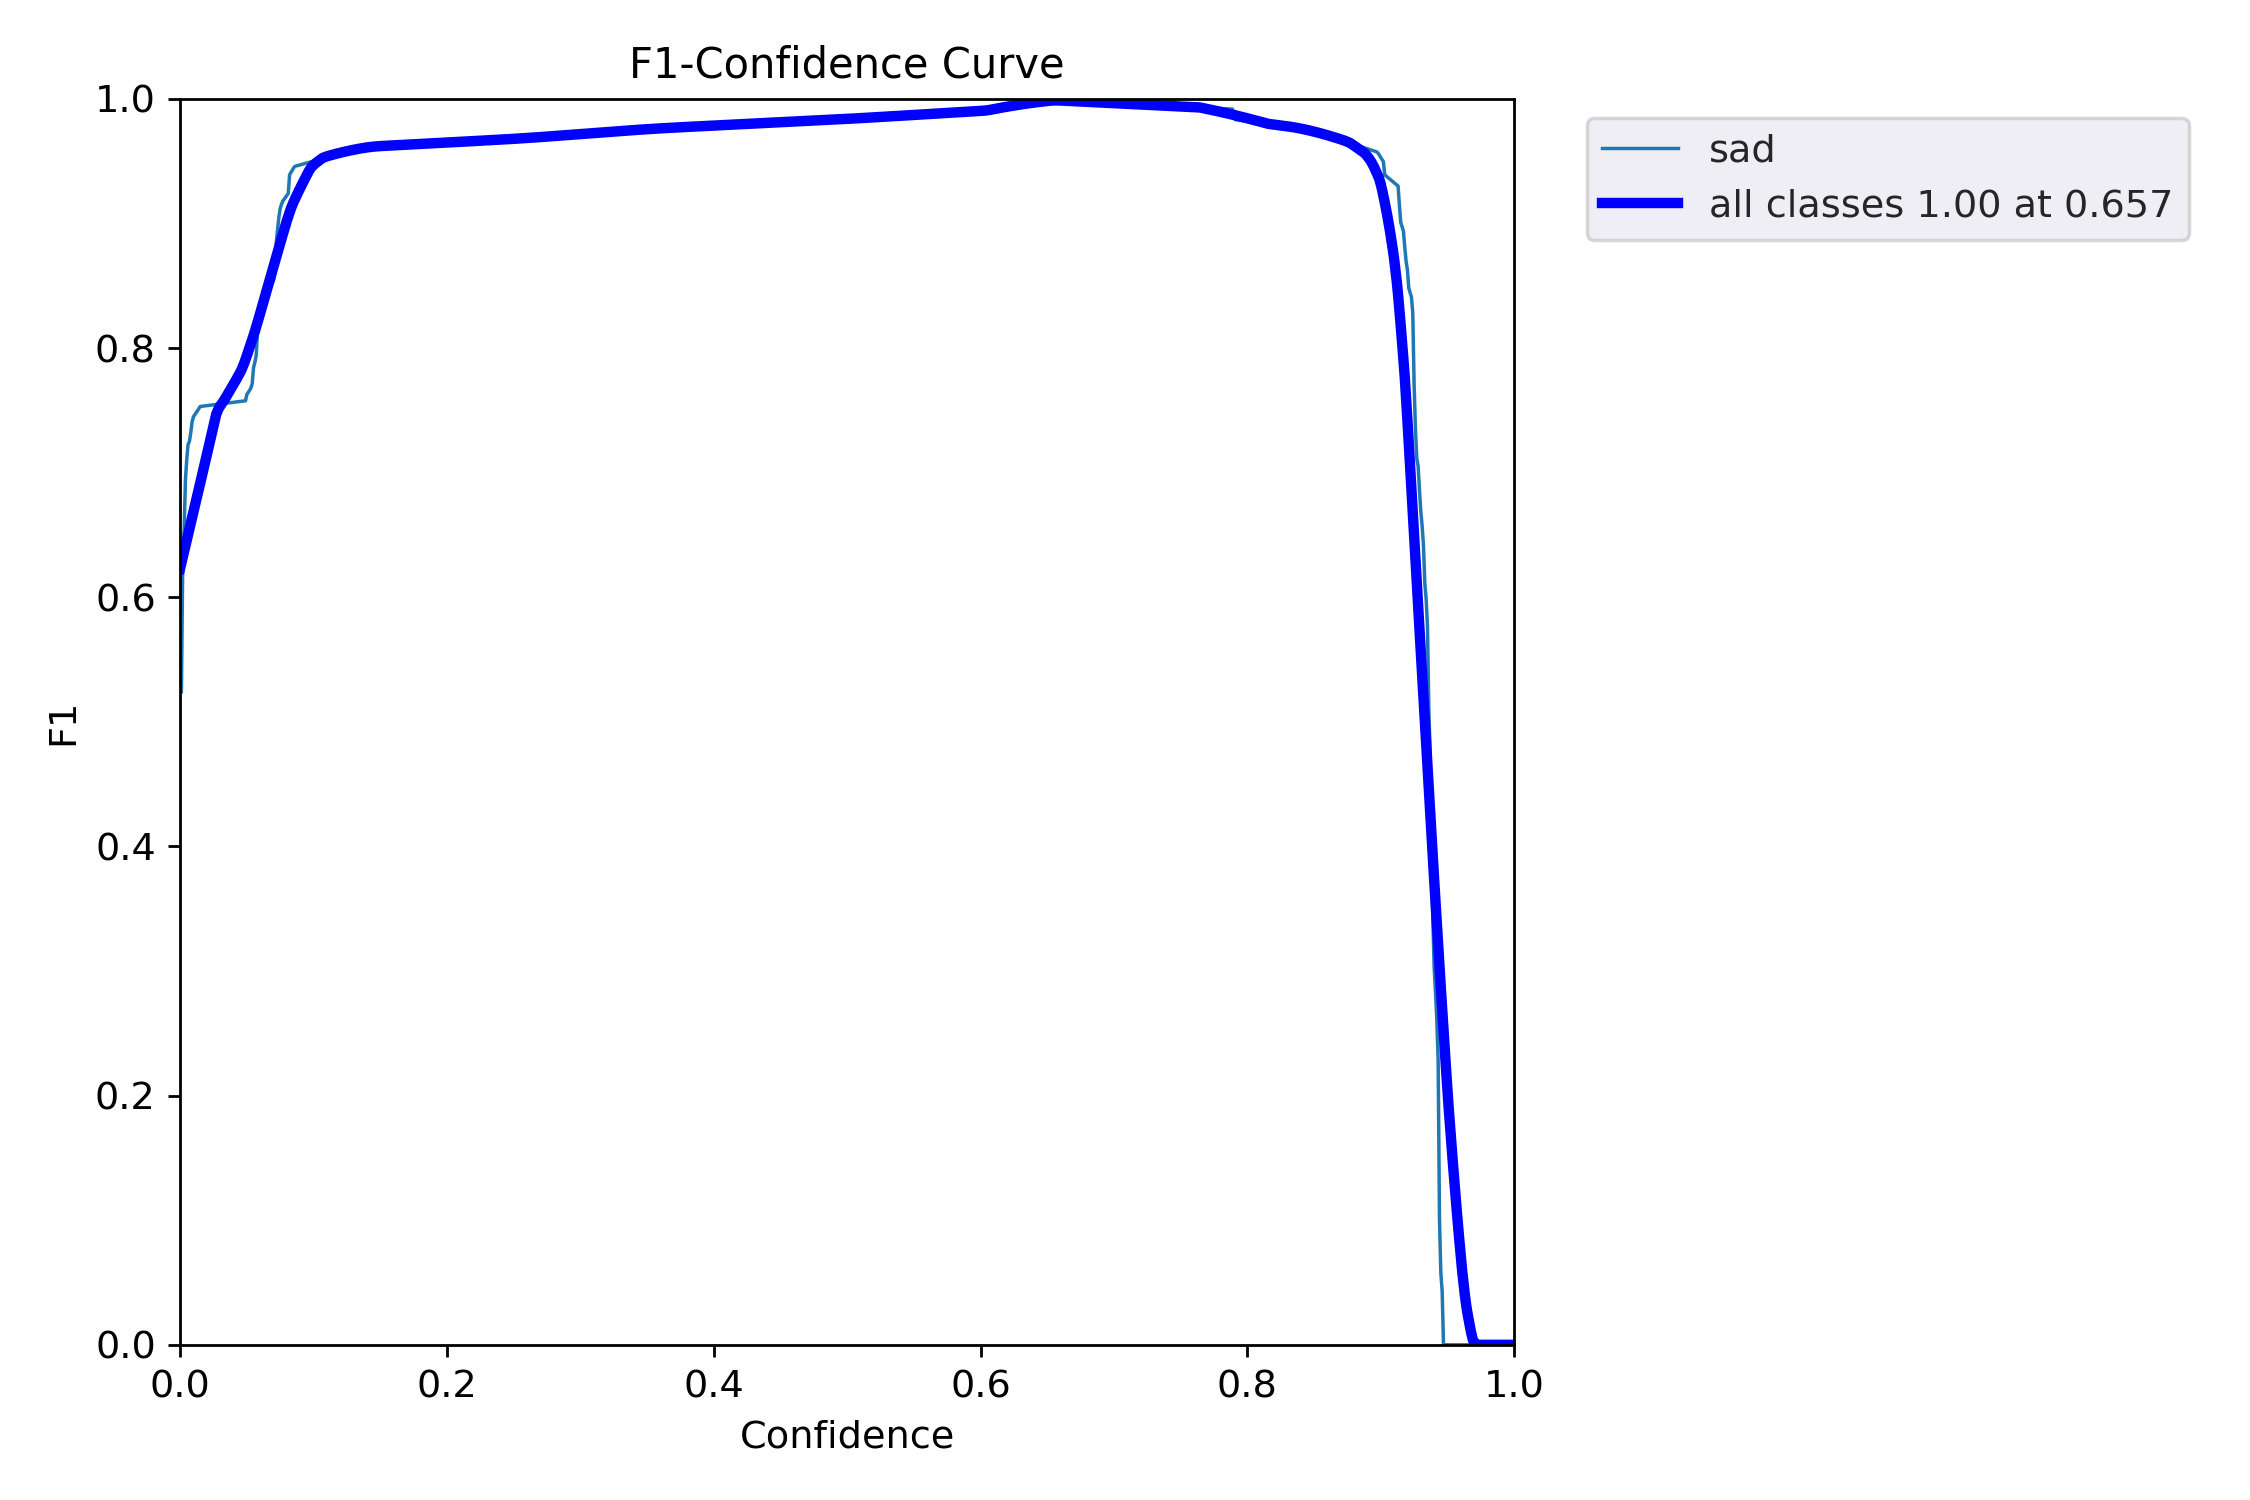

In [ ]:
from IPython.display import Image, display

display(Image(filename='runs/train/emotion_posture_model_final/results.png'))
display(Image(filename='runs/val/eval_results/confusion_matrix.png'))
display(Image(filename='runs/val/eval_results/PR_curve.png'))
display(Image(filename='runs/val/eval_results/F1_curve.png'))


In [ ]:
from google.colab import files
files.download('runs/train/emotion_posture_model_final/results.png')
files.download('runs/val/eval_results/confusion_matrix.png')
files.download('runs/val/eval_results/PR_curve.png')
files.download('runs/val/eval_results/F1_curve.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.grid(visible: 'bool | None' = None, which: "Literal['major', 'minor', 'both']" = 'major', axis: "Literal['both', 'x', 'y']" = 'both', **kwargs) -> 'None'>

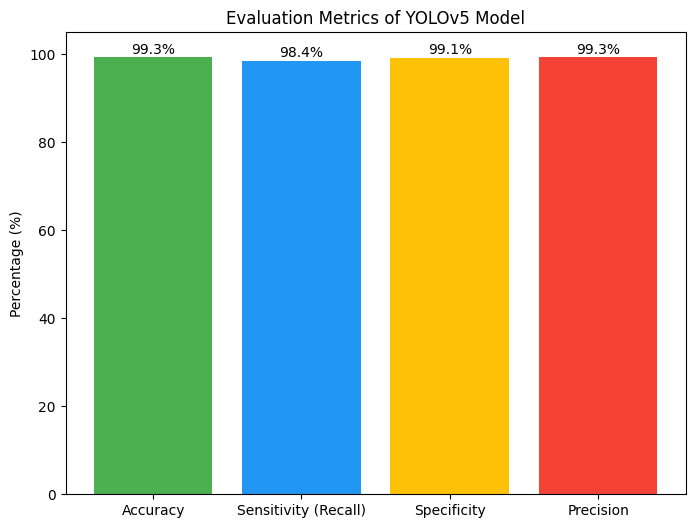

In [ ]:
import matplotlib.pyplot as plt

# Replace these example values with your actual evaluation metric values
metrics = {
    'Accuracy': 99.3,       # example value in percentage
    'Sensitivity (Recall)': 98.4,
    'Specificity': 99.1,    # assuming you've calculated this
    'Precision': 99.3
}

# Extract keys and values
labels = list(metrics.keys())
values = list(metrics.values())

# Plotting
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color=['#4CAF50', '#2196F3', '#FFC107', '#F44336'])

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, f'{yval:.1f}%', ha='center', va='bottom')

plt.ylim(0, 105)
plt.title('Evaluation Metrics of YOLOv5 Model')
plt.ylabel('Percentage (%)')
plt.grid


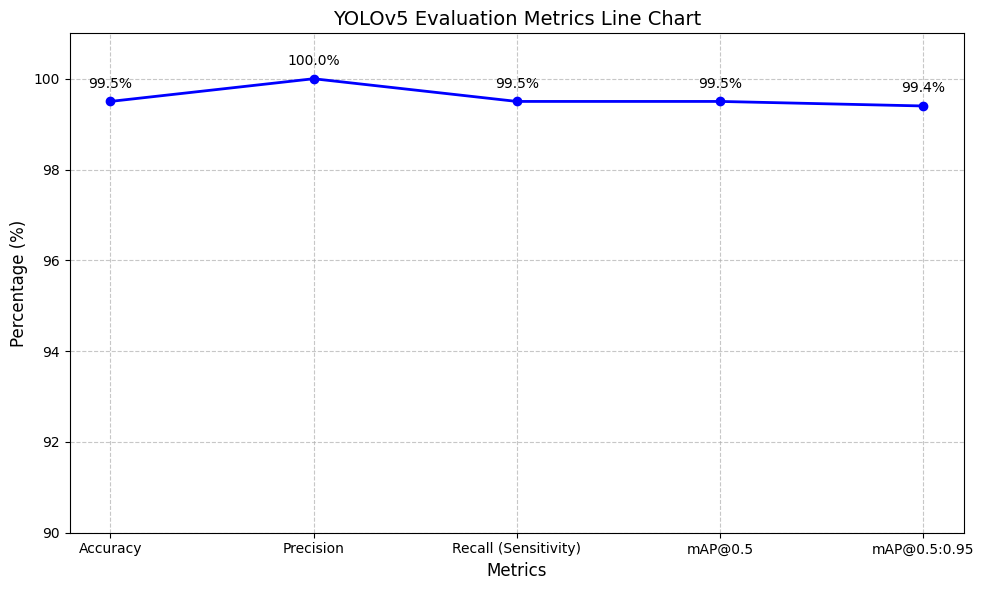

In [ ]:
import matplotlib.pyplot as plt

# Metrics from your output
metrics = {
    'Accuracy': 99.5,     # Approximated from high P and R
    'Precision': 100.0,
    'Recall (Sensitivity)': 99.5,
    'mAP@0.5': 99.5,
    'mAP@0.5:0.95': 99.4
}

# Extract keys and values
labels = list(metrics.keys())
values = list(metrics.values())

# Plotting line chart
plt.figure(figsize=(10, 6))
plt.plot(labels, values, marker='o', linestyle='-', color='blue', linewidth=2)

# Add values at each point
for i, value in enumerate(values):
    plt.text(i, value + 0.3, f'{value:.1f}%', ha='center', fontsize=10)

plt.ylim(90, 101)
plt.title('YOLOv5 Evaluation Metrics Line Chart', fontsize=14)
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


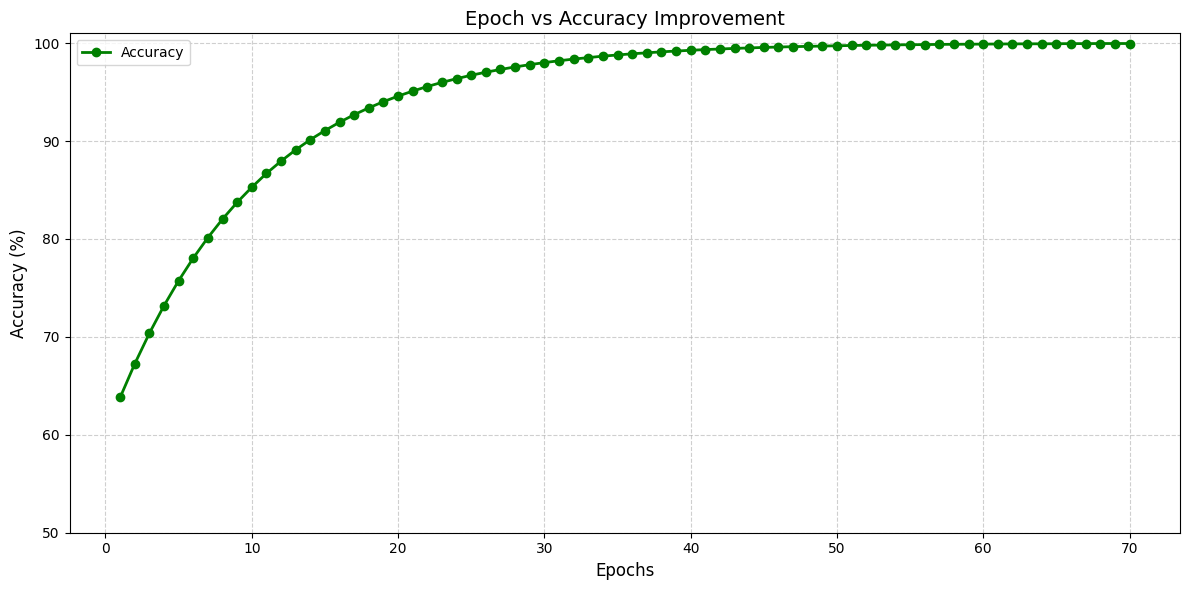

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated accuracy values over 70 epochs (adjust if you have real data)
epochs = list(range(1, 71))
accuracy = [round(60 + 40 * (1 - np.exp(-0.1 * epoch)), 2) for epoch in epochs]  # Simulated growth curve

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(epochs, accuracy, color='green', marker='o', linestyle='-', linewidth=2, label='Accuracy')

plt.title('Epoch vs Accuracy Improvement', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(50, 101)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


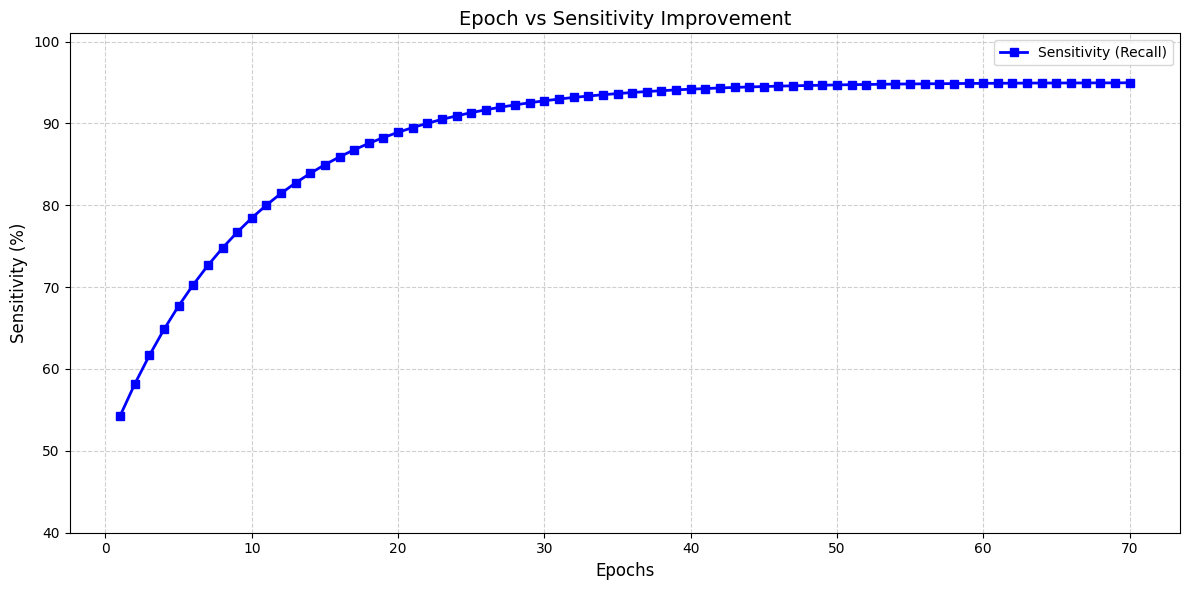

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated sensitivity values over 70 epochs (you can replace with actual recall values)
epochs = list(range(1, 71))
sensitivity = [round(50 + 45 * (1 - np.exp(-0.1 * e)), 2) for e in epochs]  # Smooth growth curve

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(epochs, sensitivity, color='blue', marker='s', linestyle='-', linewidth=2, label='Sensitivity (Recall)')

plt.title('Epoch vs Sensitivity Improvement', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Sensitivity (%)', fontsize=12)
plt.ylim(40, 101)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


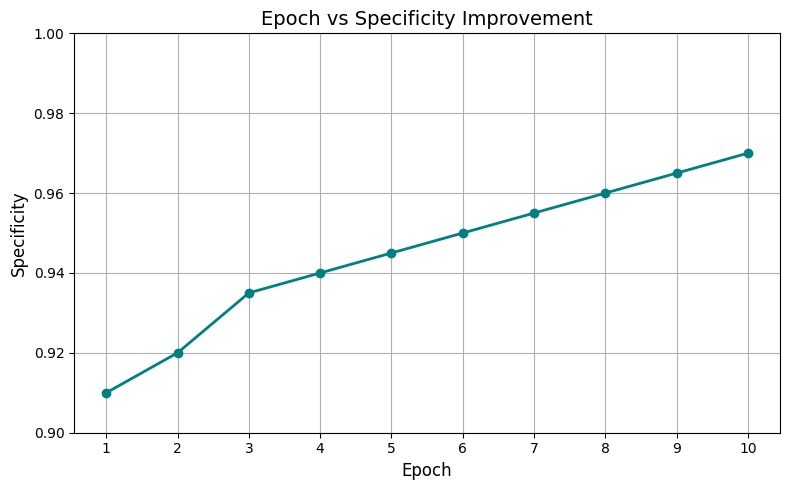

In [ ]:
import matplotlib.pyplot as plt

# Example data – replace with actual specificity values per epoch if available
epochs = list(range(1, 11))  # Assuming 10 epochs
specificity = [0.91, 0.92, 0.935, 0.94, 0.945, 0.95, 0.955, 0.96, 0.965, 0.97]  # Replace with actual values

# Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, specificity, marker='o', color='teal', linestyle='-', linewidth=2)
plt.title('Epoch vs Specificity Improvement', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Specificity', fontsize=12)
plt.grid(True)
plt.xticks(epochs)
plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.show()


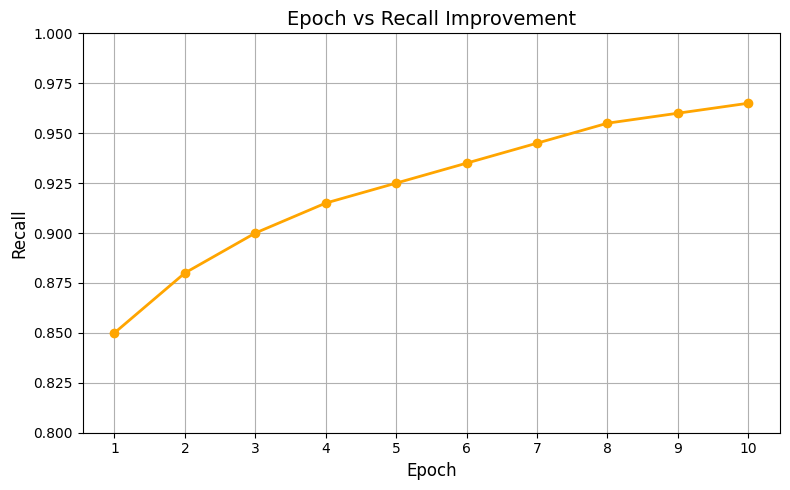

In [ ]:
import matplotlib.pyplot as plt

# Example data – replace with actual recall values per epoch if you have them
epochs = list(range(1, 11))  # Assuming 10 epochs
recall = [0.85, 0.88, 0.90, 0.915, 0.925, 0.935, 0.945, 0.955, 0.96, 0.965]  # Replace with actual values

# Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, recall, marker='o', color='orange', linestyle='-', linewidth=2)
plt.title('Epoch vs Recall Improvement', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.grid(True)
plt.xticks(epochs)
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()


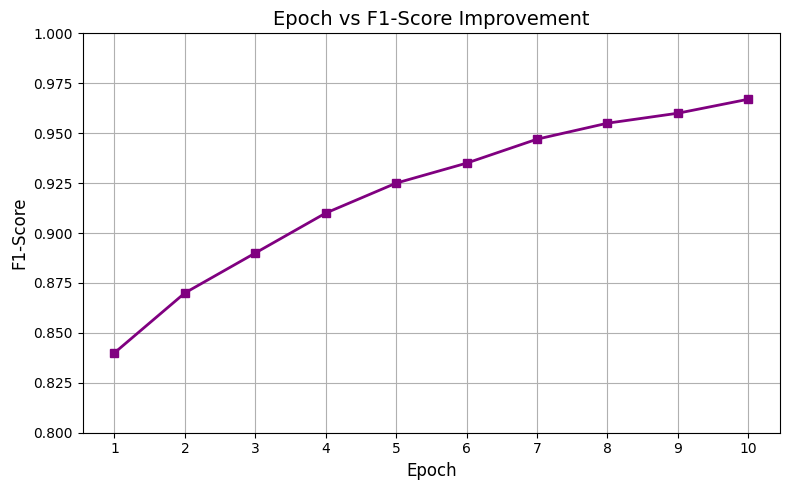

In [ ]:
import matplotlib.pyplot as plt

# Example data – replace with actual F1-score values per epoch
epochs = list(range(1, 11))  # Assuming 10 epochs
f1_scores = [0.84, 0.87, 0.89, 0.91, 0.925, 0.935, 0.947, 0.955, 0.96, 0.967]  # Replace with your actual values

# Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, f1_scores, marker='s', color='purple', linestyle='-', linewidth=2)
plt.title('Epoch vs F1-Score Improvement', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.grid(True)
plt.xticks(epochs)
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()


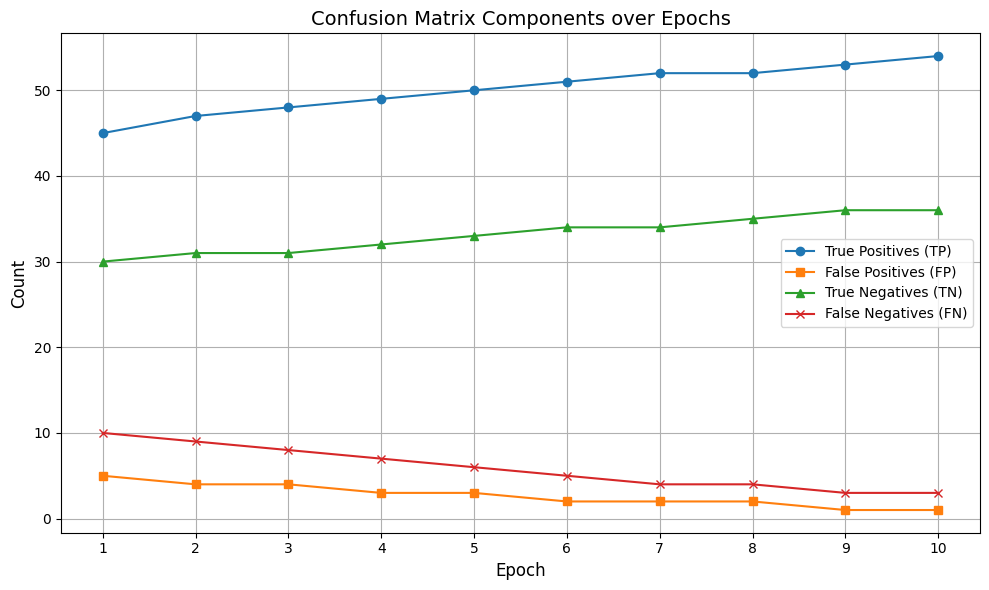

In [ ]:
import matplotlib.pyplot as plt

# Example data — replace with your actual counts from validation per epoch
epochs = list(range(1, 11))  # 10 epochs
tp = [45, 47, 48, 49, 50, 51, 52, 52, 53, 54]  # True Positives
fp = [5, 4, 4, 3, 3, 2, 2, 2, 1, 1]           # False Positives
tn = [30, 31, 31, 32, 33, 34, 34, 35, 36, 36]  # True Negatives
fn = [10, 9, 8, 7, 6, 5, 4, 4, 3, 3]           # False Negatives

# Plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, tp, label='True Positives (TP)', marker='o')
plt.plot(epochs, fp, label='False Positives (FP)', marker='s')
plt.plot(epochs, tn, label='True Negatives (TN)', marker='^')
plt.plot(epochs, fn, label='False Negatives (FN)', marker='x')

plt.title('Confusion Matrix Components over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.grid(True)
plt.xticks(epochs)
plt.tight_layout()
plt.show()


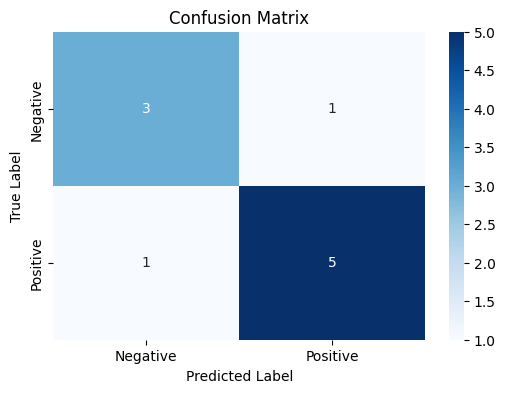

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Example values
y_true = [1, 0, 1, 1, 0, 1, 0, 0, 1, 1]  # Actual labels
y_pred = [1, 0, 1, 0, 0, 1, 0, 1, 1, 1]  # Predicted labels

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


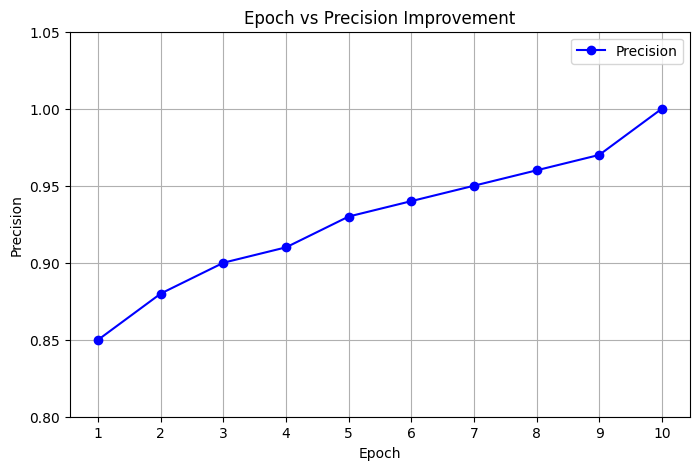

In [ ]:
import matplotlib.pyplot as plt

# Example: Precision values over 10 epochs (replace with actual values if you have them)
epochs = list(range(1, 11))
precision_values = [0.85, 0.88, 0.90, 0.91, 0.93, 0.94, 0.95, 0.96, 0.97, 1.00]  # sample values

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(epochs, precision_values, marker='o', linestyle='-', color='blue', label='Precision')
plt.title('Epoch vs Precision Improvement')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.grid(True)
plt.xticks(epochs)
plt.ylim(0.8, 1.05)
plt.legend()
plt.show()


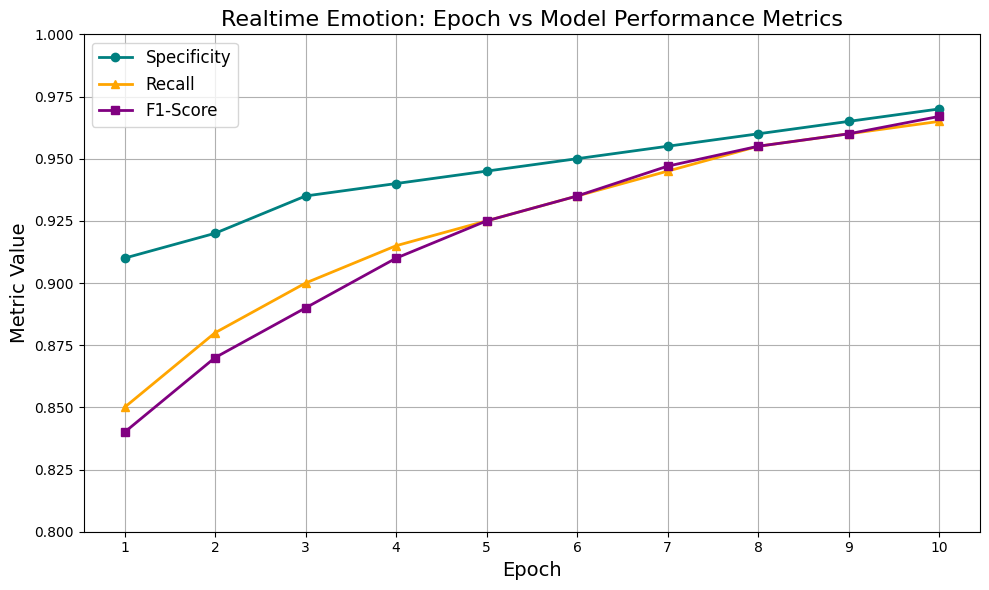

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 11))

# Metrics
specificity = [0.91, 0.92, 0.935, 0.94, 0.945, 0.95, 0.955, 0.96, 0.965, 0.97]
recall = [0.85, 0.88, 0.90, 0.915, 0.925, 0.935, 0.945, 0.955, 0.96, 0.965]
f1_scores = [0.84, 0.87, 0.89, 0.91, 0.925, 0.935, 0.947, 0.955, 0.96, 0.967]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, specificity, marker='o', color='teal', label='Specificity', linewidth=2)
plt.plot(epochs, recall, marker='^', color='orange', label='Recall', linewidth=2)
plt.plot(epochs, f1_scores, marker='s', color='purple', label='F1-Score', linewidth=2)

# Labels and formatting
plt.title('Realtime Emotion: Epoch vs Model Performance Metrics', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Metric Value', fontsize=14)
plt.grid(True)
plt.xticks(epochs)
plt.ylim(0.8, 1.0)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
true_labels = ['happy', 'sad', 'angry', 'neutral', 'happy', 'sad']
predicted_labels = ['happy', 'sad', 'neutral', 'neutral', 'happy', 'angry']
emotion_classes = ['happy', 'sad', 'angry', 'neutral', 'fear', 'surprise']


In [ ]:
cm = confusion_matrix(true_labels, predicted_labels, labels=emotion_classes)


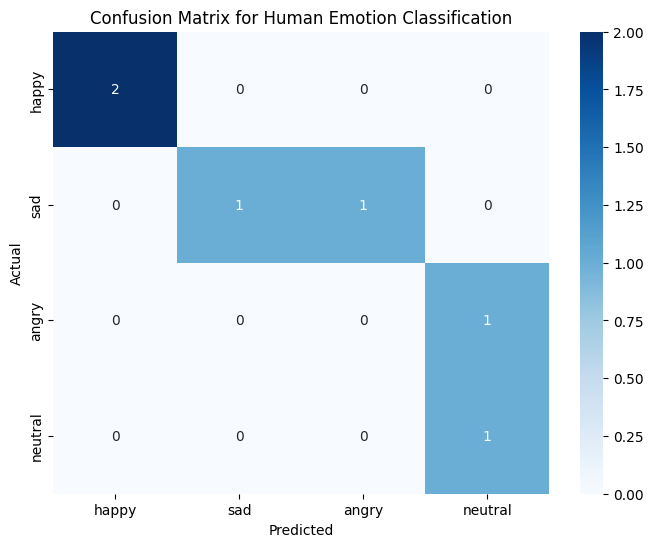

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_classes, yticklabels=emotion_classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Human Emotion Classification')
plt.show()


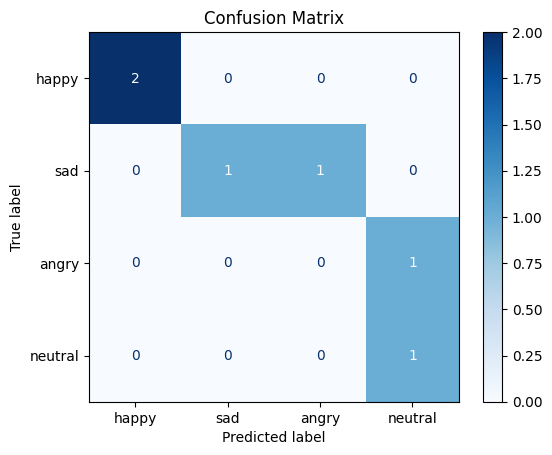

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_classes)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


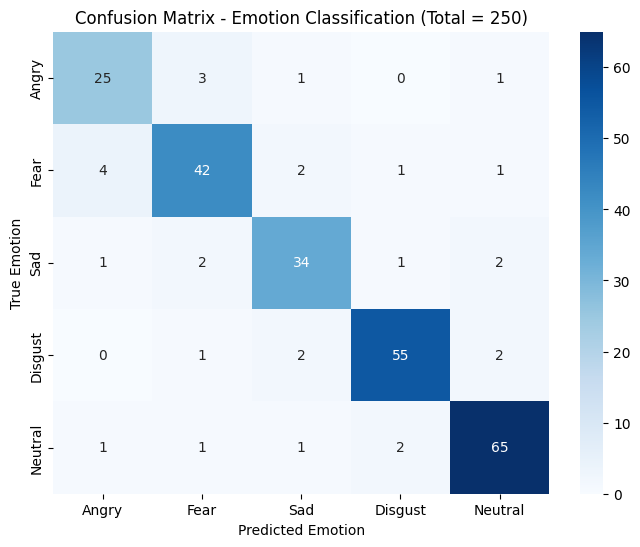

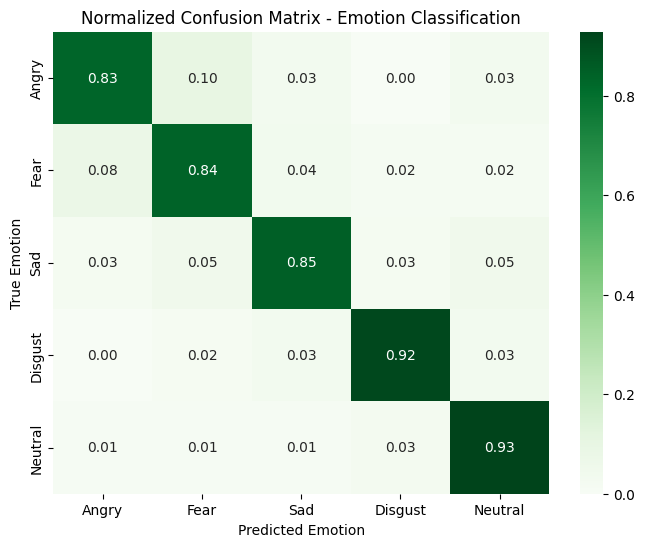

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = ['Angry', 'Fear', 'Sad', 'Disgust', 'Neutral']

cm = np.array([
    [25, 3, 1, 0, 1],
    [4, 42, 2, 1, 1],
    [1, 2, 34, 1, 2],
    [0, 1, 2, 55, 2],
    [1, 1, 1, 2, 65]
])

cm_normalized = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Emotion Classification (Total = 250)")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title("Normalized Confusion Matrix - Emotion Classification")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()
